In [33]:
import pandas as pd
import matplotlib.pyplot as plt

## СМОТРИМ ДАННЫЕ ДЛЯ BERT

In [34]:
data_labeled = pd.read_csv('final_df.csv')
data_labeled

,doc_id,chunk_id,is_macro,chunk_text
0,0,0,True,"""Индекс Мосбиржи -3%. Это самое большое дневно..."
1,2,0,True,"""С 5 февраля ЕС вводит эмбарго на российские п..."
2,2,1,True,Госбюджет РФ рискует недополучить еще больше н...
3,4,2,False,"Катализатора для реализации нашей идеи нет, по..."
4,5,0,True,"""Окно закрывается. С начала СВО физлица вывели..."
...,...,...,...,...
2304,1498,0,False,"""Вероятность перемирия России и Украины до 19 ..."
2305,1499,0,False,"""Потрясения в банковской сфере США вновь оказы..."
2306,1499,1,False,"Между тем, обеспокоенность по поводу потолка а..."
2307,1499,2,False,"Среди лидеров падения: PacWest Bancorp (-26,5%..."


In [35]:
data_labeled[data_labeled['doc_id'] == 10]['chunk_text']

,chunk_text
11,"""​​Сургутнефтегаз: что будет с дивидендами по ..."
12,И именно поэтому крупные дивиденды по префам б...
13,"Получается, что префы Сургутнефтегаза могут за..."


In [36]:
data_labeled[data_labeled['doc_id'] == 10]['chunk_text'][11]

'"\u200b\u200bСургутнефтегаз: что будет с дивидендами по префам? Сегодня компания впервые более чем за год выпустила финансовую отчетность — по РСБУ за 2022 год. На наш взгляд, отчет сильный, из-за чего вероятность выплаты крупных дивидендов за 2023 год возросла. Что показал отчет  За счет благоприятной конъюнктуры на нефтяных рынках в 2022-м Сургутнефтегаз показал мощный рост финансовых показателей:  выручка +24% г/г (до 2,33 трлн руб.);  операционная прибыль +33% г/г (до 524 млрд руб.). Тем временем чистая прибыль снизилась более чем в 8 раз (до 60,7 млрд руб.). Но это во многом связано с валютной переоценкой денежных запасов — они сократились из-за укрепления рубля. В этом же году ситуация может быть обратной. Почему  Ранее мы уже отмечали, что у Сургутнефтегаза есть крупный депозит в долларах, который компания собирала в течение долгих лет с доходов от продажи нефти.'

In [37]:
data_labeled[data_labeled['doc_id'] == 10]['chunk_text'][12]

'И именно поэтому крупные дивиденды по префам будут возможны, только если рубль за год ослабнет. Мы подсчитали, какими могут быть дивиденды по префам в зависимости от валютного курса. Если валютный курс на конец 2023-го будет таким же, как и в начале года (около 70 руб./доллар), то префы смогут принести только 3% див. доходности. Если валютный курс будет на уровне среднего нашего прогноза на 2023 год (около 76 руб./доллар), то див. доходность префов может превысить 10%. Если валютный курс сохранится на текущих уровнях (около 83 руб./доллар), то див. доходность составит уже 21%. Если же доллар укрепится до 90 руб./доллар (наименее вероятный сценарий), то префы могут принести доходность аж 30%. Получается, что префы Сургутнефтегаза могут защитить от ослабления рубля и в целом помочь диверсифицировать портфель. Мы сохраняем торговую идею на покупку этих бумаг с таргетом 40 руб./преф.'

In [38]:
data_labeled[data_labeled['doc_id'] == 10]['chunk_text'][13]

'Получается, что префы Сургутнефтегаза могут защитить от ослабления рубля и в целом помочь диверсифицировать портфель. Мы сохраняем торговую идею на покупку этих бумаг с таргетом 40 руб./преф. С учетом текущих уровней котировок и валютного курса инвесторы могут получить доходность 34,7% (14% за счет роста акций + 20,7% за счет возможных дивидендов за 2023 год). Алдар Цыбиков, аналитик Тинькофф Инвестиций  Другие торговые идеи на российском рынке можете найти в нашей стратегии-2023. #россия #идея"'

In [39]:
data_labeled[data_labeled['doc_id'] == 1499]['chunk_text'][2305]

'"Потрясения в банковской сфере США вновь оказывают давление на рынок, а стоимость нефти упала до мартовских значений Главные новости зарубежных рынков к этому утру  Фондовые индексы США снизились во вторник S&P 500 потерял 1,2%, а высокотехнологичный Nasdaq и индекс Dow Jones снизились на 1,1%. Инвесторы сохраняют сдержанный настрой в преддверии предстоящего решения Федеральной резервной системы по процентным ставкам. Несмотря на продолжающийся в США банковский кризис участники рынка ожидают, что ФРС повысит ставки еще на 0,25%. Между тем, обеспокоенность по поводу потолка американского государственного долга также начинает оказывать некоторое давление на рынки, замечает SeekingAlpha.'

In [40]:
data_labeled[data_labeled['doc_id'] == 1499]['chunk_text'][2306]

'Между тем, обеспокоенность по поводу потолка американского государственного долга также начинает оказывать некоторое давление на рынки, замечает SeekingAlpha. Акции Азии снижаются, кроме Японии   Широкий индекс акций Азии (за исключением Японии) MSCI AC Asia ex Japan Index потерял сегодня 0,8%, южнокорейский Kospi упал на 0,9%, сингапурский STI сократился на 0,9%, гонконгский Hang Seng снизился на 1,6%, а японский Nikkei вырос на 0,1%. Все из-за признаков ослабления американской экономики, а также новых проблем в банковском секторе США. Акции региональных банков США резко упали во вторник По итогам вчерашней торговой сессии отраслевой индекс — S&P Regional Banks — снизился примерно на 7%. Среди лидеров падения: PacWest Bancorp (-26,5%), Western Alliance Bancorp (-20,4%) и New York Community Bancorp (-7%). Не остались в стороне и крупные американские банки.'

In [41]:
data_labeled[data_labeled['doc_id'] == 1499]['chunk_text'][2307]

'Среди лидеров падения: PacWest Bancorp (-26,5%), Western Alliance Bancorp (-20,4%) и New York Community Bancorp (-7%). Не остались в стороне и крупные американские банки. Акции Wells Fargo упали на 4,7%, бумаги Citigroup и Bank of America снизились на 3,1% и 3,9% соответственно, а капитализация JPMorgan уменьшилась на 1,7%. Падение акций банков из США возобновилось после краха First Republic Bank — крупнейшего банкротства американского банка со времен финансового кризиса 2008 года. Между тем участники рынка опасаются, что банковский кризис все еще далек от завершения. Акции американских энергетических компаний снижаются на фоне падения нефтяных цен По итогам вчерашних торгов отраслевой индекс — S&P 500 Energy — снизился на 1,4%.'

In [42]:
data_labeled[data_labeled['doc_id'] == 1499]['chunk_text'][2308]

'Акции американских энергетических компаний снижаются на фоне падения нефтяных цен По итогам вчерашних торгов отраслевой индекс — S&P 500 Energy — снизился на 1,4%. Среди акций крупных энергетических компаний США в лидерах падения во вторник: Halliburton (-7,4%), Schlumberger (-6,2%), APA Corporation (-6,6%), EOG Resources (-5,3%) и Marathon Oil (-5,1%). Крупнейшие энергетические компании США — Chevron и Exxon Mobil — также снижались вчера (на 4% и 3,3% соответственно). Падение акций американских энергетических компаний происходит на фоне снижения нефтяных цен. По итогам вчерашних торгов фьючерсы на Brent подешевели на 5% до $75,32 за баррель, а контракты на WTI снизились на 5,3% до $71,66.'

## ИТОГ: ЧАНКЕР ВЫГЛЯДИТ ОЧЕНЬ УБЕДИТЕЛЬНО НА БОЛЬШИХ ТЕКСТАХ

In [43]:
data_labeled

,doc_id,chunk_id,is_macro,chunk_text
0,0,0,True,"""Индекс Мосбиржи -3%. Это самое большое дневно..."
1,2,0,True,"""С 5 февраля ЕС вводит эмбарго на российские п..."
2,2,1,True,Госбюджет РФ рискует недополучить еще больше н...
3,4,2,False,"Катализатора для реализации нашей идеи нет, по..."
4,5,0,True,"""Окно закрывается. С начала СВО физлица вывели..."
...,...,...,...,...
2304,1498,0,False,"""Вероятность перемирия России и Украины до 19 ..."
2305,1499,0,False,"""Потрясения в банковской сфере США вновь оказы..."
2306,1499,1,False,"Между тем, обеспокоенность по поводу потолка а..."
2307,1499,2,False,"Среди лидеров падения: PacWest Bancorp (-26,5%..."


In [44]:
## 35% ЧАНКОВ С МАКРО НОВОСТЯМИ, ОТЛИЧНО ДЛЯ ОБУЧЕНИЯ
data_labeled['is_macro'].mean()

np.float64(0.35210047639670855)

In [45]:
data_grouped_doc = data_labeled.groupby(by='doc_id', as_index=False).agg({'is_macro': 'sum'})

In [46]:
(data_grouped_doc['is_macro'] > 0).mean()

np.float64(0.36502820306204675)

## ВЫВОД: ВСЕ ДОСТАТОЧНО СТАБИЛЬНО, ПРОЦЕНТ МАКРО НОВОСТЕЙ ПО ДОКУМЕНТАМ И ПО ЧАНКАМ ПО ОТДЕЛЬНОСТИ СОВПАДАЕТ

## ПОСМОТРИМ НА СТАБИЛЬНОСТЬ РАЗМЕТКИ

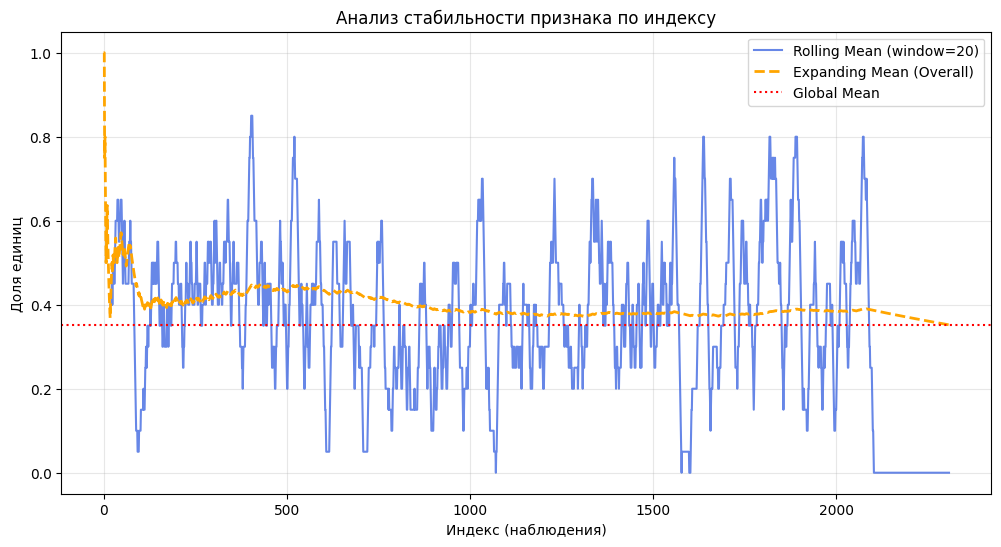

In [47]:
window_size = 20

# Расчет метрик
rolling_avg = data_labeled['is_macro'].rolling(window=window_size).mean()
expanding_avg = data_labeled['is_macro'].expanding().mean()

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(rolling_avg.values, label=f'Rolling Mean (window={window_size})', color='royalblue', alpha=0.8)
plt.plot(expanding_avg.values, label='Expanding Mean (Overall)', color='orange', linestyle='--', linewidth=2)

plt.axhline(y=data_labeled['is_macro'].mean(), color='red', linestyle=':', label='Global Mean')

plt.title('Анализ стабильности признака по индексу')
plt.xlabel('Индекс (наблюдения)')
plt.ylabel('Доля единиц')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

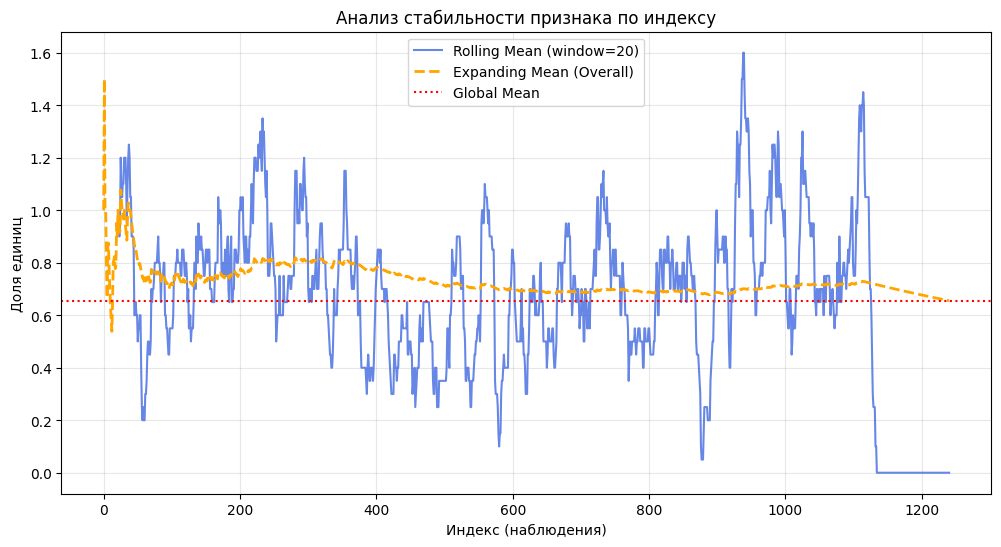

In [48]:
window_size = 20

# Расчет метрик для группированных данных
rolling_avg = data_grouped_doc['is_macro'].rolling(window=window_size).mean()
expanding_avg = data_grouped_doc['is_macro'].expanding().mean()

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(rolling_avg.values, label=f'Rolling Mean (window={window_size})', color='royalblue', alpha=0.8)
plt.plot(expanding_avg.values, label='Expanding Mean (Overall)', color='orange', linestyle='--', linewidth=2)

plt.axhline(y=data_grouped_doc['is_macro'].mean(), color='red', linestyle=':', label='Global Mean')

plt.title('Анализ стабильности признака по индексу')
plt.xlabel('Индекс (наблюдения)')
plt.ylabel('Доля единиц')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## ИТОГ: РАЗМЕЧЕННЫЙ ПРИЗНАК ВЫГЛЯДИТ СТАБИЛЬНО